In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate

#### Function to calculate input and output phase difference.

In [14]:
amu, ps, cm, Å =  1836.0, 41341.37, 1/0.000004556, 1.8897259885789
ω = 360/cm  # Phonon Frequency Used 
Angle = 0.0  # 90 degrees in radians
Scale = 1 # Phonon coupling strength expressed on the scale used in this work
Gamma = 1.1 * (ω)**1.5 * (Scale) # Phonon Coupling Considered
def plot_phase_shift(angle, gamma):
    c1 = np.loadtxt(f'./Data/c_1_5_{angle}_{gamma}.txt')
    c2 = np.loadtxt(f'./Data/c_2_5_{angle}_{gamma}.txt')
    cδ1 = np.loadtxt(f'./Data/c_δ1_5_{angle}_{gamma}.txt')
    cδ2 = np.loadtxt(f'./Data/c_δ2_5_{angle}_{gamma}.txt')
    phi = np.angle(c1[:, 0] + 1j*c1[:, 1], True)
    phi2 = np.angle(c2[:, 0] + 1j*c2[:, 1], True)
    phiδ1 = np.angle(cδ1[:, 0] + 1j*cδ1[:, 1], True)
    phiδ2 = np.angle(cδ2[:, 0] + 1j*cδ2[:, 1], True) 
    def wrap_to_2pi(angle):
        """Converts an angle from [-pi, pi] to [0, 2*pi]."""
        return np.fmod(angle + 360, 360)
    θ1 = wrap_to_2pi(-phi + phi2)
    θ2 = wrap_to_2pi(-phiδ1 + phiδ2)
    t1, t2 = 17, 22
    dθ1 = (θ1[t2] - θ1[t1])/(t2 - t1)
    dθ2 = (θ2[t2] - θ2[t1])/(t2 - t1)
    OutputΘ = (θ2[t1] - dθ2 * t1) * np.pi / 180
    InputΘ = (θ1[t1] - dθ1 * t1) * np.pi / 180
    return InputΘ, OutputΘ

### FIG 4 (k-l)

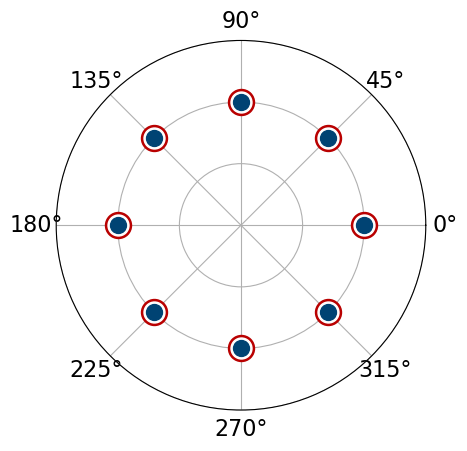

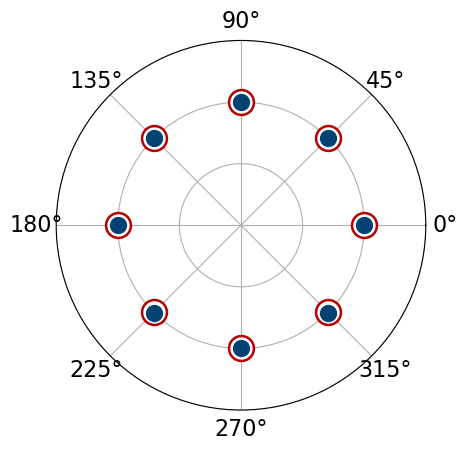

In [15]:
Angle = np.array([0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5]) *np.pi /2 # angles in radians
Scale = np.array([0,4])
Gamma = 1.1 * (ω)**1.5 * (Scale)
Angle2 = np.array([0.0, 2.0]) *np.pi /2 # angles in radians

for k in range(len(Scale)):
    fig = plt.figure()
    ax = fig.add_subplot(projection='polar')       # set up polar axes
    for j in range(len(Angle)):

        InputΘ, OutputΘ = plot_phase_shift(Angle[j], Gamma[k])
        #ax.scatter(InputΘ, .66667, s = 200, zorder = 10, facecolors='none', edgecolors="#b90000") #ee5253 replaced #b90000 and #2e86de replaced #004373 LOOKS BAD
        ax.scatter(InputΘ, .66667, s = 200 * 1.75, zorder = 10, c ="#b90000") 
        ax.scatter(InputΘ, .66667, s = 130 * 1.75, zorder = 11, c ="white")
        ax.scatter(OutputΘ, .66667, s = 75 * 1.75, zorder = 12, c ="#004373")
        #ax.scatter(OutputΘ, .66667, s = 40, zorder = 11, c ='#3742fa', marker='x')
        ax.set_yticks(np.linspace(0, 1, 4), [])
    plt.savefig(f'./Plots/Phase_Diagram_{Gamma[k]}.pdf')
    plt.show()



### FIG 4 (b)

<>:16: SyntaxWarning: invalid escape sequence '\R'
<>:16: SyntaxWarning: invalid escape sequence '\R'
/var/folders/p4/8yg25rhd2c9_jwylfb7fmpph0000gp/T/ipykernel_84370/383632195.py:16: SyntaxWarning: invalid escape sequence '\R'
  plt.ylabel("$\Re(c(t))$")


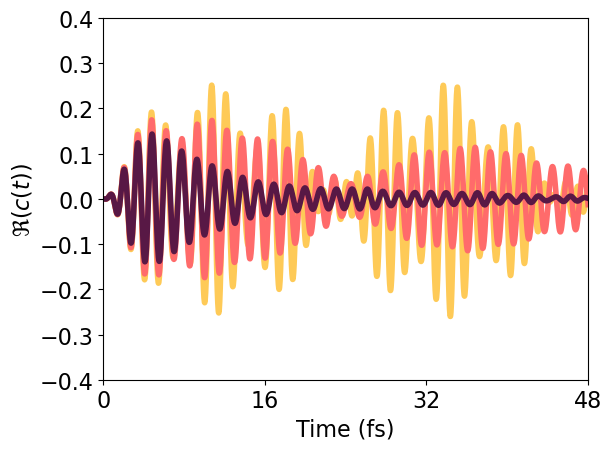

In [16]:
Angle3 = np.array([0.0]) *np.pi /2 # angles in radians
Scale3 = np.array([1,4,8]) # Phonon coupling strength expressed on the scale used in this work
Gamma3 = 1.1 * (ω)**1.5 * (Scale3)
Xmin = 0
Xmax = 2000
colors = ["#feca57", "#ff6b6b", "#581845"]
for k in range(len(Angle3)):
    for j in range(len(Scale3)):
        Output = np.loadtxt(f'./Data/c_δ1_5_{Angle3[k]}_{Gamma3[j]}.txt')
        plt.rcParams.update({'font.size': 16})
        plt.rcParams.update({'font.family': 'sans-serif'})
        
        plt.plot(np.real(Output[:, 0]), c = colors[j], lw = 4)
        plt.xlim(Xmin, Xmax)
        plt.xlabel("Time (fs)")
        plt.ylabel("$\Re(c(t))$")
        plt.tight_layout()
        plt.xticks(
        ticks=np.linspace(Xmin,Xmax, 4),
        labels=[f"{int(t * 1 * 1/41.34137)}" for t in np.linspace(Xmin,Xmax, 4)]
        )
        plt.ylim(-0.4, 0.4)
    plt.savefig(f'./Plots/Decoherance.pdf')
    plt.show()


#### Fig 4 (c-j)

<>:20: SyntaxWarning: invalid escape sequence '\R'
<>:33: SyntaxWarning: invalid escape sequence '\R'
<>:20: SyntaxWarning: invalid escape sequence '\R'
<>:33: SyntaxWarning: invalid escape sequence '\R'
/var/folders/p4/8yg25rhd2c9_jwylfb7fmpph0000gp/T/ipykernel_84370/2605648528.py:20: SyntaxWarning: invalid escape sequence '\R'
  plt.ylabel("$\Re(c(t))$")
/var/folders/p4/8yg25rhd2c9_jwylfb7fmpph0000gp/T/ipykernel_84370/2605648528.py:33: SyntaxWarning: invalid escape sequence '\R'
  plt.ylabel("$\Re(c(t))$")


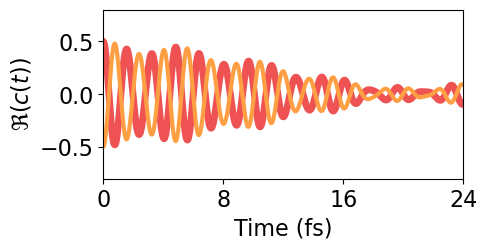

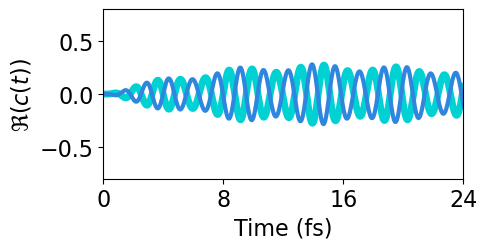

In [17]:
θr = 2* np.pi/2 # Input the theta value
scale = 0 # Input the scale value
γ = 1.1 * (ω)**1.5 * scale 
rho_sum1 = np.loadtxt(f'./Data/c_1_5_{θr}_{γ}.txt')[:,0]
rho_sum2 = np.loadtxt(f'./Data/c_2_5_{θr}_{γ}.txt')[:,0]
rho_sumδ = np.loadtxt(f'./Data/c_δ1_5_{θr}_{γ}.txt')[:,0]
rho_sumδ2 = np.loadtxt(f'./Data/c_δ2_5_{θr}_{γ}.txt')[:,0]
plt.figure(figsize=(5, 2.5))
plt.plot((rho_sum1.real ), label='c_1', c = "#ee5253", lw = 5)
plt.plot((rho_sum2.real), label='c_2', c = "#ff9f43", lw = 3)
Xmin = 0
Xmax = 1000
plt.xlim(Xmin, Xmax)
plt.tight_layout()
plt.xticks(
    ticks=np.linspace(Xmin,Xmax, 4),
    labels=[f"{int(t /41.34137)}" for t in np.linspace(Xmin,Xmax, 4)]
)
plt.xlabel("Time (fs)")
plt.ylabel("$\Re(c(t))$")
plt.ylim(-.8,.8)
plt.savefig(f'./Plots/input_{θr}_20_{γ}.pdf', bbox_inches='tight')
plt.show()
#####
plt.figure(figsize=(5, 2.5))
plt.plot((rho_sumδ.real ), label='c_δ', c = "#00d2d3", lw = 5)
plt.plot((rho_sumδ2.real ), label='c_δ2', c = "#2e86de", lw = 3)
plt.xlim(Xmin, Xmax)
plt.ylim(-0.8,0.8)
plt.tight_layout()
plt.xticks(ticks=np.linspace(Xmin, Xmax, 4),labels=[f"{int(t /41.34137)}" for t in np.linspace(Xmin, Xmax, 4)])   
plt.xlabel("Time (fs)")
plt.ylabel("$\Re(c(t))$")
plt.savefig(f'./Plots/output_{θr}_20_{γ}.pdf', bbox_inches='tight')
plt.show()